In [1]:
%pip install numpy qiskit qiskit-aer
%pip install pylatexenc

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import MCMT, ZGate, XGate 
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram
import math
from qiskit.visualization import plot_histogram
from qiskit import transpile


In [3]:
def create_oracle(vertex_number, edge_number, edges, target_number):
    
    count_qubit = vertex_number.bit_length()

    vertex_register = QuantumRegister(vertex_number, name = "vr")
    edge_register = QuantumRegister(edge_number, name = "er")
    count_register = QuantumRegister(count_qubit, name = "cr")
    target_register = QuantumRegister(1, name = "target")

    oracle = QuantumCircuit(vertex_register, edge_register, count_register, target_register, name="oracle")

    # if u == 0 && v == 0 => edge[idx] = 1 means the edge is illegal
    for idx, (u, v) in enumerate(edges):
        oracle.x(vertex_register[u])
        oracle.x(vertex_register[v])
        oracle.ccx(vertex_register[u], vertex_register[v], edge_register[idx])
        oracle.x(vertex_register[u])
        oracle.x(vertex_register[v])

    # check the chosen vertex number
    for v_idx in range(vertex_number):
        for c_idx in reversed(range(1, count_qubit)):
            controls = [vertex_register[v_idx]] + count_register[:c_idx][:]
            oracle.mcx(controls, count_register[c_idx])
        oracle.cx(vertex_register[v_idx], count_register[0])

    binary_target = format(target_number, f'0{count_qubit}b')[::-1]

    for i, bit in enumerate(binary_target):
        if bit == '0':
            oracle.x(count_register[i])


    oracle.x(edge_register) # if the edge = 0 means illegal

    controls = edge_register[:] + count_register[:]
    oracle.mcx(controls, target_register) # if all edge = 1 (all legal) ,then target return -1

    

    # let all the qubit back to it original state
    oracle.x(edge_register)

    for i, bit in enumerate(binary_target):
        if bit == '0':
            oracle.x(count_register[i])


    for v_idx in reversed(range(vertex_number)):
        for c_idx in reversed(range(1, count_qubit)):               
            for i in range(c_idx):
                oracle.x(count_register[i])                         
            controls = [vertex_register[v_idx]] + [count_register[i] for i in range(c_idx)]
            oracle.mcx(controls, count_register[c_idx])
            for i in range(c_idx):
                oracle.x(count_register[i])                         
        oracle.cx(vertex_register[v_idx], count_register[0])    
    
    for idx, (u, v) in enumerate(edges):
        oracle.x(vertex_register[u])
        oracle.x(vertex_register[v])
        oracle.ccx(vertex_register[u], vertex_register[v], edge_register[idx])
        oracle.x(vertex_register[u])
        oracle.x(vertex_register[v]) 
        
    return oracle.to_gate()



In [4]:
def create_diffuser(vertex_number):

    diffusion_register = QuantumRegister(vertex_number, name="dr")
    diffuser = QuantumCircuit(diffusion_register, name="diffuser")

    diffuser.h(diffusion_register)
    diffuser.x(diffusion_register)
    diffuser.h(diffusion_register[-1])
    diffuser.mcx(diffusion_register[:-1], diffusion_register[-1])
    diffuser.h(diffusion_register[-1])
    diffuser.x(diffusion_register)
    diffuser.h(diffusion_register)

    return diffuser.to_gate()

In [5]:
def read_graph_with_params(filepath):
    with open(filepath, 'r', encoding='utf-8-sig') as f:
        lines = f.readlines()
        a, b, M = map(int, lines[0].split())   
        k = int(lines[1].strip())              
        edges = [tuple(map(int, line.strip().split())) for line in lines[2:]]
    return a, b, M, k, edges

In [6]:
filepath = "data/graph4.txt"
vertex_number, edge_number, M, target_number, edges = read_graph_with_params(filepath)

N = 2 ** vertex_number
R = math.floor((math.pi / 4) * math.sqrt(N / M))

print(f"vertex numbers: {vertex_number}, edge numbers: {edge_number}, answer numbers: {M}")
print(f"best iteration times: {R}")

count_qubit = vertex_number.bit_length()

vertex_register = QuantumRegister(vertex_number, name = "vr")
edge_register = QuantumRegister(edge_number, name = "er")
count_register = QuantumRegister(count_qubit, name = "cr")
target_register = QuantumRegister(1, name = "target")
classical_register = ClassicalRegister(vertex_number, name = "classic")

qc = QuantumCircuit(vertex_register, edge_register,count_register, target_register, classical_register)

qc.h(vertex_register)

qc.x(target_register)
qc.h(target_register)

qc.barrier()

for i in range (R):
    qc.append(create_oracle(vertex_number, edge_number, edges, target_number), vertex_register[:] + edge_register[:] + count_register[:] +target_register[:])
    qc.append(create_diffuser(vertex_number), vertex_register[:])

qc.measure(vertex_register, classical_register)

vertex numbers: 6, edge numbers: 6, answer numbers: 7
best iteration times: 2


top 7 vertex set：
  rk.1  chosen vertex：100101  times：1513  probability：15.13%
  rk.2  chosen vertex：100011  times：1439  probability：14.39%
  rk.3  chosen vertex：010011  times：1438  probability：14.38%
  rk.4  chosen vertex：001011  times：1432  probability：14.32%
  rk.5  chosen vertex：001101  times：1369  probability：13.69%
  rk.6  chosen vertex：010101  times：1352  probability：13.52%
  rk.7  chosen vertex：000111  times：1340  probability：13.40%


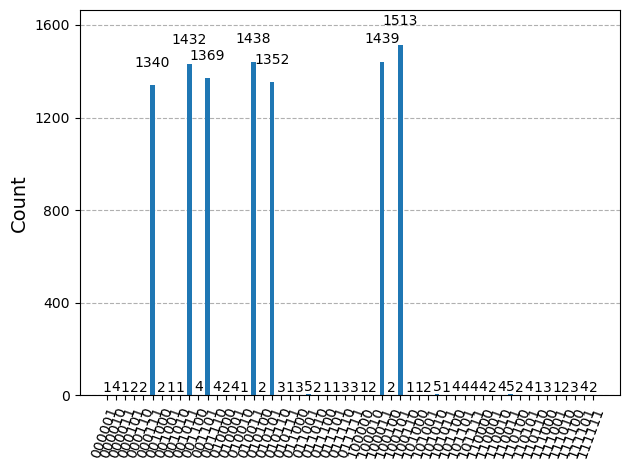

In [7]:
simulator = AerSimulator()

compiled_qc = transpile(qc, simulator)

result = simulator.run(compiled_qc, shots=10000).result()

counts = result.get_counts(compiled_qc)

top_M = dict(sorted(counts.items(), key=lambda x: x[1], reverse=True)[:M])

print(f"top {M} vertex set：")
for rank, (bitstring, count) in enumerate(top_M.items(), 1):
    vertex_bits = bitstring[-vertex_number:]  
    print(f"  rk.{rank}  chosen vertex：{vertex_bits}  times：{count}  probability：{count/10000:.2%}")


plot_histogram(counts)